<a href="https://colab.research.google.com/github/meriem-mb/Deep-Learning-Exam/blob/main/Benaatit_Meriem_Examen_DLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time

In [8]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1477s 9us/step
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


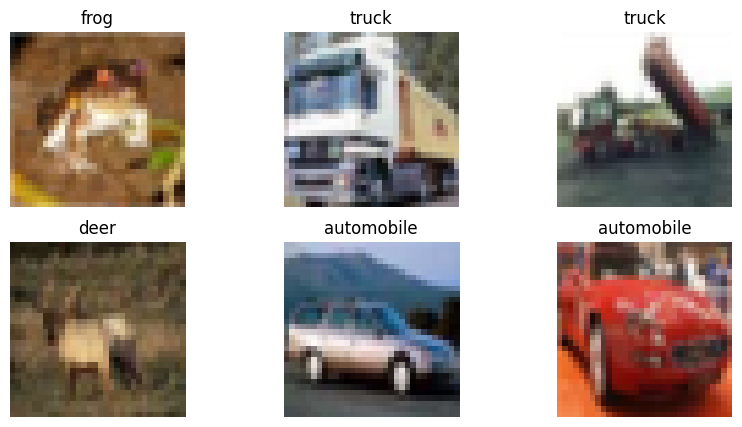

In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [10]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [11]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model1 = keras.Model(inputs=inputs, outputs=outputs)
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

start = time.time()
history1 = model1.fit(X_train, y_train,
                      epochs=10,
                      validation_data=(X_test, y_test))
time1 = time.time() - start
print("Model 1 training time (seconds):", time1)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4302 - loss: 1.5700 - val_accuracy: 0.5280 - val_loss: 1.3198
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5541 - loss: 1.2628 - val_accuracy: 0.5606 - val_loss: 1.2487
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5966 - loss: 1.1486 - val_accuracy: 0.5885 - val_loss: 1.1566
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6267 - loss: 1.0623 - val_accuracy: 0.6063 - val_loss: 1.1186
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6499 - loss: 1.0026 - val_accuracy: 0.6232 - val_loss: 1.0814
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6678 - loss: 0.9506 - val_accuracy: 0.6256 - val_loss: 1.0646
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6829 - loss: 0.9128 - val_accuracy: 0.6391 - val_loss: 1.0371
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6933 - loss: 0.8810 

In [13]:
test_loss1, test_acc1 = model1.evaluate(X_test, y_test)
print("Model 1 test accuracy:", test_acc1)
print("Model 1 test loss:", test_loss1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6301 - loss: 1.0746
Model 1 test accuracy: 0.6301000118255615
Model 1 test loss: 1.074629783630371


In [14]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model2 = keras.Model(inputs=inputs, outputs=outputs)

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

start = time.time()
history2 = model2.fit(X_train, y_train,
                      epochs=10,
                      validation_data=(X_test, y_test))
time2 = time.time() - start
print("Model 2 training time (seconds):", time2)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4417 - loss: 1.5263 - val_accuracy: 0.5277 - val_loss: 1.3058
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5840 - loss: 1.1720 - val_accuracy: 0.6143 - val_loss: 1.0919
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6349 - loss: 1.0337 - val_accuracy: 0.6212 - val_loss: 1.0815
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6728 - loss: 0.9290 - val_accuracy: 0.6572 - val_loss: 1.0003
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6966 - loss: 0.8628 - val_accuracy: 0.6846 - val_loss: 0.9052
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7158 - loss: 0.8067 - val_accuracy: 0.6978 - val_loss: 0.8730
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7342 - loss: 0.7585 - val_accuracy: 0.6903 - val_loss: 0.8890
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7481 - loss: 0.7208 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7118 - loss: 0.8647
Model 2 test accuracy: 0.7117999792098999
Model 2 test loss: 0.8646561503410339
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


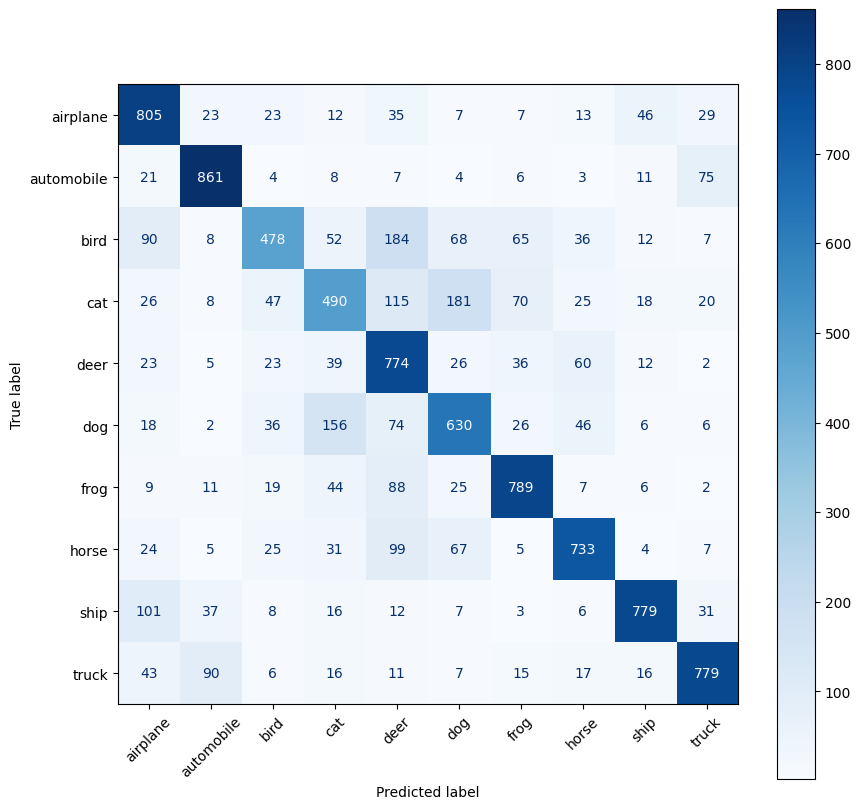

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loss2, test_acc2 = model2.evaluate(X_test, y_test)
print("Model 2 test accuracy:", test_acc2)
print("Model 2 test loss:", test_loss2)

y_pred = model2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.show()

In [16]:
print("Conv layers   -> Model 1: 1     | Model 2: 3")
print("Test accuracy -> Model 1: {:.3f} | Model 2: {:.3f}".format(test_acc1, test_acc2))
print("Train time (s)-> Model 1: {:.1f}  | Model 2: {:.1f}".format(time1, time2))

Conv layers   -> Model 1: 1     | Model 2: 3
Test accuracy -> Model 1: 0.630 | Model 2: 0.712
Train time (s)-> Model 1: 68.3  | Model 2: 75.8
